# Trabajo práctico 1 - Minería de Datos
Primer Cuatrimestre - Año 2026

Integrantes:

- Lara Onyskiw
- Sebastián Muñoz

### Importación de paquetes y Dataset

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
data = pd.read_csv("dxCropRecommendation.csv")
data.head()

,Nitrogeno,Fosforo,Potasio,Temperatura,Humedad,pH,Lluvia,Cultivo
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Arroz
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Arroz
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Arroz
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Arroz
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Arroz


### Análisis exploratorio y limpieza de datos

In [3]:
print(f"Filas, columnas: {data.shape} \n ")
print(f"Tipos de datos: \n {data.dtypes}")

Filas, columnas: (1210, 8) 
 
Tipos de datos: 
 Nitrogeno        int64
Fosforo          int64
Potasio          int64
Temperatura    float64
Humedad        float64
pH             float64
Lluvia         float64
Cultivo            str
dtype: object


In [4]:
print(f"Cantidad de valores nulos por columna: \n {data.isna().sum()}")

Cantidad de valores nulos por columna: 
 Nitrogeno      0
Fosforo        0
Potasio        0
Temperatura    0
Humedad        1
pH             4
Lluvia         3
Cultivo        0
dtype: int64


In [5]:
# Filas que tienen al menos un valor faltante
data_con_nan = data[data.isna().any(axis=1)]

display(data_con_nan)

,Nitrogeno,Fosforo,Potasio,Temperatura,Humedad,pH,Lluvia,Cultivo
772,1,35,34,30.793757,46.695368,NaN,92.213186,Mango
777,8,38,32,29.751508,46.737233,4.981817,NaN,Mango
794,0,36,26,34.130722,51.257862,NaN,NaN,Mango
844,20,142,196,10.898759,NaN,NaN,NaN,Uva
880,6,140,205,17.665584,82.929034,NaN,69.867126,Uva


Al analizar los valores faltantes observamos que las columnas afectadas son Humedad, pH y Lluvia. Dado que se trata de variables numéricas continuas y que el conjunto de datos fue modificado intencionalmente, descartamos eliminar los registros, ya que implicaría perder observaciones válidas de clases específicas. En su lugar, decidimos imputar los valores faltantes utilizando la mediana agrupada por Cultivo. Esta decisión permite conservar la estructura propia de cada clase y reduce la influencia de posibles valores extremos, especialmente en variables como Lluvia y Humedad, que pueden presentar distribuciones asimétricas.

In [6]:
# Columnas numéricas con valores faltantes
columnas_con_nulos = ['Humedad', 'pH', 'Lluvia']

for columna in columnas_con_nulos:
    data[columna] = data.groupby('Cultivo')[columna].transform(
        lambda x: x.fillna(x.median())
    )

data.isna().sum()

Nitrogeno      0
Fosforo        0
Potasio        0
Temperatura    0
Humedad        0
pH             0
Lluvia         0
Cultivo        0
dtype: int64

In [7]:
# Cantidad de duplicados

print(f"Cantidad de registros duplicados: {data.duplicated().sum()}")
data[data.duplicated(keep=False)].sort_values(by=list(data.columns))

Cantidad de registros duplicados: 10


,Nitrogeno,Fosforo,Potasio,Temperatura,Humedad,pH,Lluvia,Cultivo
740,5,16,31,35.960546,48.696778,4.555689,98.006442,Mango
744,5,16,31,35.960546,48.696778,4.555689,98.006442,Mango
738,12,31,26,35.787774,51.941903,5.395276,100.216061,Mango
742,12,31,26,35.787774,51.941903,5.395276,100.216061,Mango
739,12,34,28,33.361401,45.022364,6.135269,98.815965,Mango
743,12,34,28,33.361401,45.022364,6.135269,98.815965,Mango
206,32,73,81,20.450786,15.403121,5.988993,92.683737,Garbanzo
301,32,73,81,20.450786,15.403121,5.988993,92.683737,Garbanzo
404,32,76,15,28.051536,63.498022,7.604110,43.357954,Lenteja
405,32,76,15,28.051536,63.498022,7.604110,43.357954,Lenteja


Al analizar los registros duplicados detectamos 10 observaciones repetidas de forma exacta. Al visualizar los casos con keep=False, observamos 20 filas, ya que se muestran tanto los registros originales como sus respectivas "copias". Dado que los duplicados coinciden en todas las variables predictoras y también en la clase Cultivo, decidimos eliminarlos conservando únicamente la primera aparición. Esta decisión evita que ciertos perfiles de suelo y clima tengan un peso artificial dentro del entrenamiento y permite trabajar con un conjunto limpio antes de avanzar hacia el análisis de outliers, escalado y modelado.

In [8]:
# Eliminamos duplicados exactos, conservando la primera aparición
data = data.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Dimensión luego de eliminar duplicados: {data.shape}")
print(f"Duplicados restantes: {data.duplicated().sum()}")

Dimensión luego de eliminar duplicados: (1200, 8)
Duplicados restantes: 0


En primer lugar analizamos la cantidad de registros por cultivo luego del tratamiento de nulos y duplicados. Esta revisión permite verificar la distribución de la variable objetivo y evaluar si existe desbalance entre clases. Dado que el problema es multiclase, esta información resulta necesaria para interpretar posteriormente las métricas de clasificación.

In [11]:
tabla_cultivos = (
    data['Cultivo']
    .value_counts()
    .reset_index()
)

tabla_cultivos.columns = ['Cultivo', 'Cantidad']
display(tabla_cultivos)

,Cultivo,Cantidad
0,Arroz,100
1,Maiz,100
2,Garbanzo,100
3,GranoNegro,100
4,Lenteja,100
5,Granada,100
6,Banana,100
7,Mango,100
8,Uva,100
9,Manzana,100


### Visualizaciones

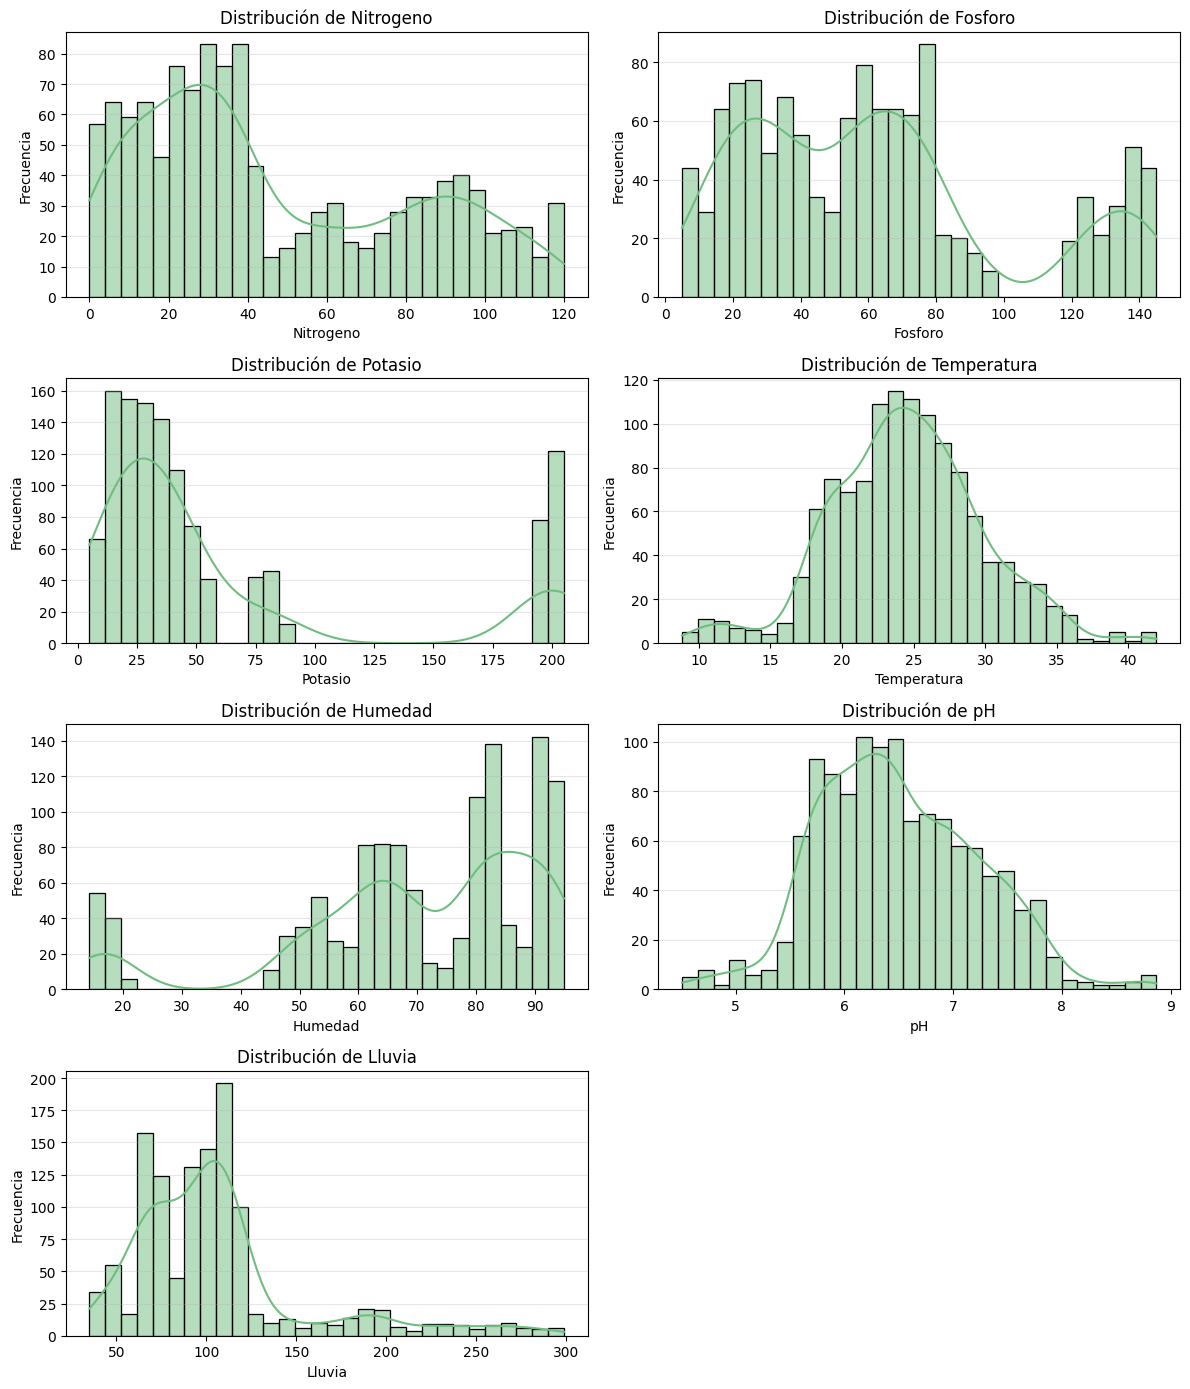

In [12]:
# Variables predictoras numéricas
variables_numericas = [
    'Nitrogeno', 'Fosforo', 'Potasio',
    'Temperatura', 'Humedad', 'pH', 'Lluvia'
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, variable in enumerate(variables_numericas):
    sns.histplot(
        data=data,
        x=variable,
        bins=30,
        kde=True,
        color='#6fbd7f',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribución de {variable}')
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.3)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


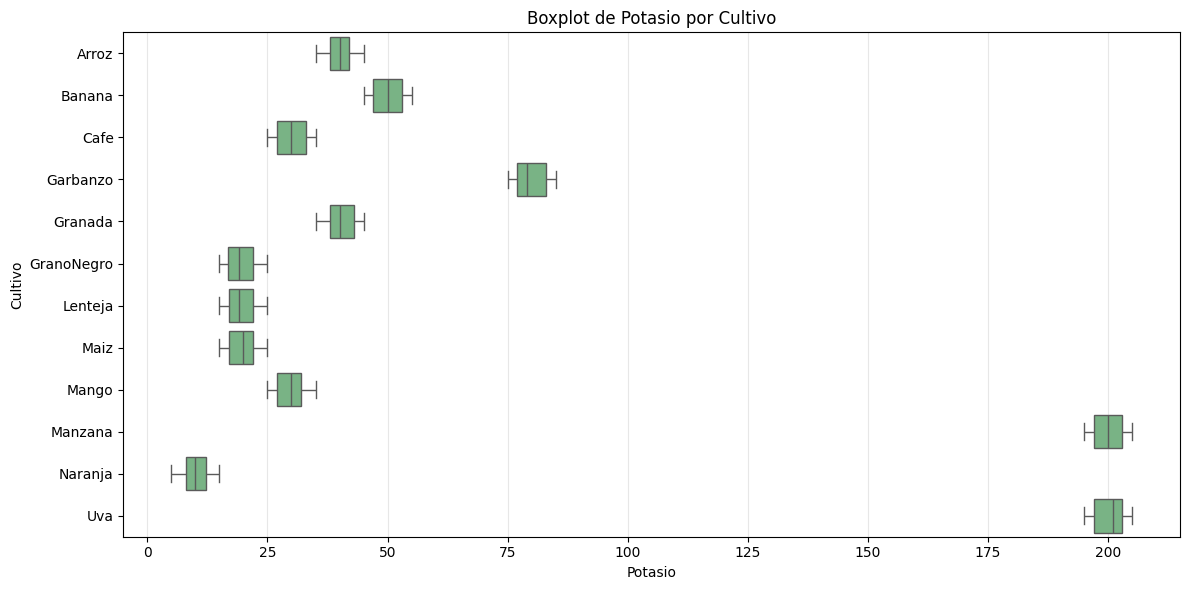

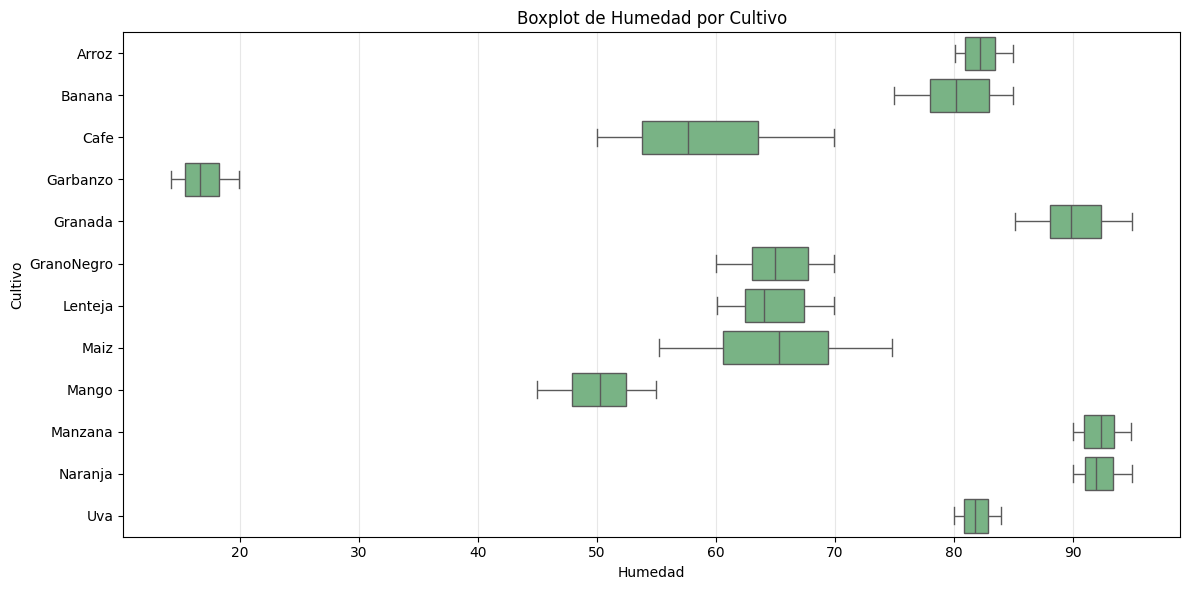

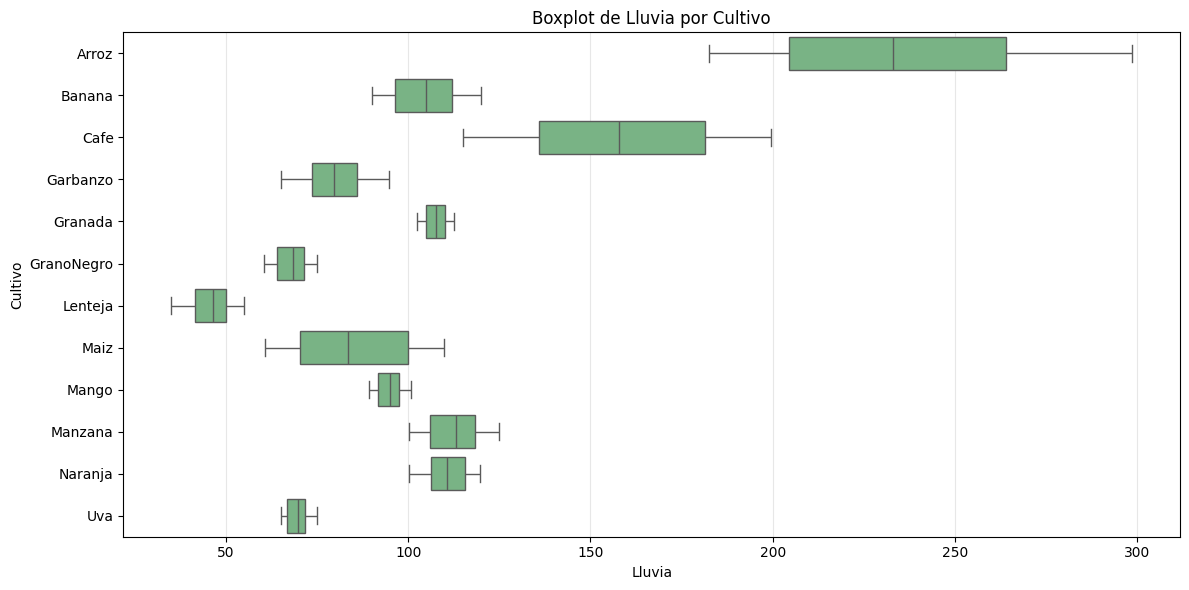

In [14]:
variables_boxplot = ['Potasio', 'Humedad', 'Lluvia']

# Ordenamos los cultivos para mantener una lectura estable
orden_cultivos = sorted(data['Cultivo'].unique())

for variable in variables_boxplot:
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=data,
        x=variable,
        y='Cultivo',
        order=orden_cultivos,
        color='#6fbd7f'
    )

    plt.title(f'Boxplot de {variable} por Cultivo')
    plt.xlabel(variable)
    plt.ylabel('Cultivo')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

A partir de los boxplots agrupados por 'Cultivo', observamos que las variables 'Potasio', 'Humedad' y 'Lluvia' presentan diferencias marcadas entre clases, pero no se identifican valores aislados por fuera de los bigotes del boxplot. Esto indica que los valores que parecían extremos en los histogramas generales no necesariamente corresponden a errores o ruido, sino que pueden formar parte del comportamiento propio de determinados cultivos.

Por este motivo, decidimos no eliminar registros en esta instancia. Complementamos la lectura visual con tablas descriptivas por variable y por cultivo. Estas tablas nos permiten revisar mínimos, máximos, medias, medianas y cuartiles, con el objetivo de confirmar si los rangos observados son coherentes dentro de cada clase.

In [19]:
variables_analisis = ['Potasio', 'Humedad', 'Lluvia']

# Generamos una tabla descriptiva por variable
for variable in variables_analisis:
    tabla_variable = (
        data
        .groupby('Cultivo')[variable]
        .describe()
        .round(2)
    )
    
    print(f'\nResumen descriptivo de {variable} por Cultivo')
    display(tabla_variable)


Resumen descriptivo de Potasio por Cultivo


,count,mean,std,min,25%,50%,75%,max
Cultivo,,,,,,,,
Arroz,100.0,39.87,2.95,35.0,38.00,40.0,42.00,45.0
Banana,100.0,50.05,3.38,45.0,47.00,50.0,53.00,55.0
Cafe,100.0,29.94,3.25,25.0,27.00,30.0,33.00,35.0
Garbanzo,100.0,79.92,3.26,75.0,77.00,79.0,83.00,85.0
Granada,100.0,40.21,3.03,35.0,38.00,40.0,43.00,45.0
GranoNegro,100.0,19.24,3.19,15.0,16.75,19.0,22.00,25.0
Lenteja,100.0,19.41,2.97,15.0,17.00,19.0,22.00,25.0
Maiz,100.0,19.79,2.94,15.0,17.00,20.0,22.00,25.0
Mango,100.0,29.92,3.10,25.0,27.00,30.0,32.00,35.0



Resumen descriptivo de Humedad por Cultivo


,count,mean,std,min,25%,50%,75%,max
Cultivo,,,,,,,,
Arroz,100.0,82.27,1.42,80.12,80.95,82.19,83.47,84.97
Banana,100.0,80.36,2.81,75.03,78.06,80.22,82.96,84.98
Cafe,100.0,58.87,5.84,50.05,53.81,57.65,63.58,69.95
Garbanzo,100.0,16.86,1.71,14.26,15.39,16.66,18.27,19.97
Granada,100.0,90.13,2.83,85.13,88.10,89.91,92.43,95.00
GranoNegro,100.0,65.12,2.80,60.07,63.04,65.03,67.74,69.96
Lenteja,100.0,64.80,2.94,60.09,62.49,64.09,67.44,69.92
Maiz,100.0,65.09,5.45,55.28,60.58,65.30,69.43,74.83
Mango,100.0,50.16,2.76,45.02,47.93,50.28,52.48,54.96



Resumen descriptivo de Lluvia por Cultivo


,count,mean,std,min,25%,50%,75%,max
Cultivo,,,,,,,,
Arroz,100.0,236.18,34.29,182.56,204.33,233.12,264.13,298.56
Banana,100.0,104.63,9.40,90.11,96.47,105.01,112.09,119.85
Cafe,100.0,158.07,25.70,115.16,136.01,157.77,181.47,199.47
Garbanzo,100.0,80.06,7.94,65.11,73.61,79.69,85.82,94.78
Granada,100.0,107.53,2.90,102.52,104.97,107.59,109.96,112.48
GranoNegro,100.0,67.88,4.18,60.42,64.05,68.29,71.40,74.92
Lenteja,100.0,45.68,5.63,35.03,41.57,46.55,50.00,54.94
Maiz,100.0,84.77,15.55,60.65,70.38,83.47,99.88,109.75
Mango,100.0,94.73,3.32,89.29,91.66,95.10,97.48,100.81


Luego de analizar los histogramas, los boxplots por cultivo y los resúmenes descriptivos, no detectamos outliers evidentes que justifiquen la eliminación de registros. Las diferencias observadas responden a patrones propios de cada cultivo y no a valores aislados o inconsistentes.

Por lo tanto, conservamos la totalidad de los registros luego de la limpieza inicial de nulos y duplicados. Esta decisión permite mantener la información diferencial entre clases, que será relevante para los modelos supervisados posteriores.

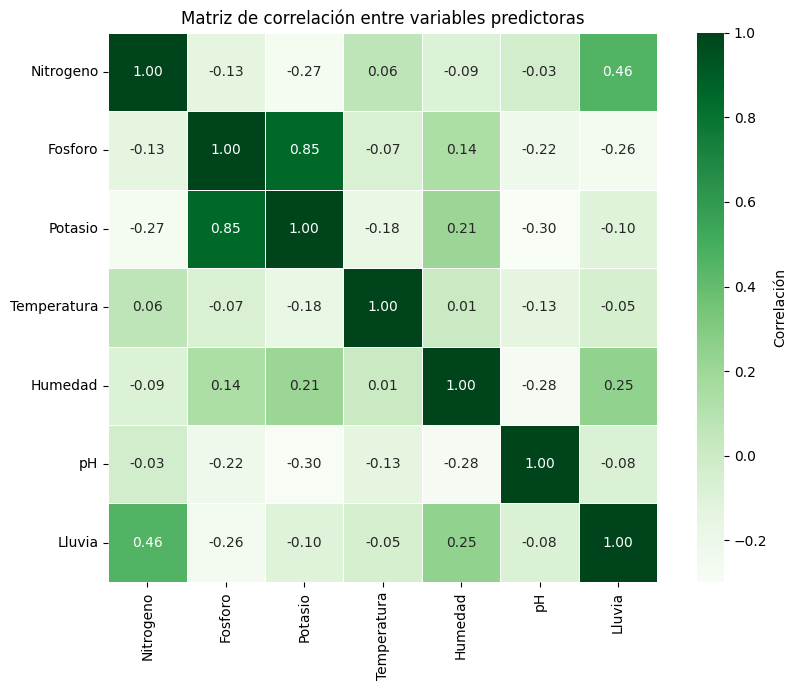

In [21]:
variables_numericas = [
    'Nitrogeno',
    'Fosforo',
    'Potasio',
    'Temperatura',
    'Humedad',
    'pH',
    'Lluvia'
]

# Calculamos la matriz de correlación entre variables predictoras
matriz_correlacion = data[variables_numericas].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlación'}
)

plt.title('Matriz de correlación entre variables predictoras')
plt.tight_layout()
plt.show()

Luego de analizar las distribuciones y revisar posibles valores atípicos, calculamos la matriz de correlación entre las variables predictoras numéricas. Esta visualización nos permite identificar asociaciones lineales entre atributos del suelo y del clima antes de avanzar hacia el escalado y el entrenamiento de los modelos.

La correlación más alta se observa entre 'Fosforo' y 'Potasio', con un valor de 0.85. Esta relación indica que ambas variables tienden a aumentar de manera conjunta, por lo que podrían estar aportando información parcialmente redundante. También se observa una correlación positiva moderada entre 'Nitrogeno' y 'Lluvia', con un valor de 0.46.

En el resto de los casos, las correlaciones son bajas o moderadas. 'Temperatura' no presenta asociaciones lineales fuertes con las demás variables, mientras que 'pH' muestra correlaciones negativas leves o moderadas con algunas variables, especialmente 'Potasio' y 'Humedad'.

A partir del EDA observamos que el conjunto limpio queda balanceado, con 100 registros por cada cultivo. Las distribuciones de las variables predictoras muestran diferencias importantes entre clases, especialmente en 'Potasio', 'Humedad' y 'Lluvia', pero no detectamos outliers evidentes que justifiquen eliminar registros. La matriz de correlación muestra una relación fuerte entre 'Fosforo' y 'Potasio', aunque decidimos conservar ambas variables para no reducir información antes del modelado.

Con estas decisiones, el dataset queda preparado para la etapa de preprocesamiento final: separación entre variables predictoras y variable objetivo, codificación de 'Cultivo' y estandarización de las características numéricas.

### Preparación final del conjunto

Separamos el conjunto de datos en 'X' e 'y'. En 'X' conservamos las siete variables numéricas que describen condiciones de suelo y clima, mientras que en 'y' dejamos la variable objetivo 'Cultivo', correspondiente al cultivo recomendado.

Esta separación es necesaria para aplicar posteriormente los modelos supervisados de clasificación.

In [ ]:
variables_predictoras = [
    'Nitrogeno',
    'Fosforo',
    'Potasio',
    'Temperatura',
    'Humedad',
    'pH',
    'Lluvia'
]

X = data[variables_predictoras]
y = data['Cultivo']

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1200, 7)
Dimensión de y: (1200,)


La variable 'Cultivo' es categórica nominal y contiene 12 clases. Para dejarla preparada para los algoritmos de clasificación, aplicamos 'LabelEncoder', transformando cada cultivo en un código numérico.

Conservamos la tabla de correspondencias entre códigos y cultivos para poder interpretar correctamente las predicciones y las matrices de confusión en las etapas posteriores.

In [24]:
# Codificamos la variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Guardamos la correspondencia entre código numérico y cultivo
tabla_codificacion = pd.DataFrame({
    'Cultivo': label_encoder.classes_,
    'Codigo': range(len(label_encoder.classes_))
})

display(tabla_codificacion)

,Cultivo,Codigo
0,Arroz,0
1,Banana,1
2,Cafe,2
3,Garbanzo,3
4,Granada,4
5,GranoNegro,5
6,Lenteja,6
7,Maiz,7
8,Mango,8
9,Manzana,9


In [26]:
# Estandarizamos las variables predictoras numéricas
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=variables_predictoras,
    index=X.index
)

display(X_scaled.head())

,Nitrogeno,Fosforo,Potasio,Temperatura,Humedad,pH,Lluvia
0,1.269214,-0.506561,-0.287597,-0.700929,0.569618,0.003241,1.946122
1,1.122636,-0.093779,-0.318638,-0.530993,0.489712,0.738843,2.422447
2,0.389749,-0.171175,-0.272076,-0.295565,0.584716,1.841482,3.171650
3,0.800166,-0.687153,-0.334159,0.369635,0.482055,0.659531,2.747933
4,0.917428,-0.506561,-0.303118,-0.843936,0.550729,1.550417,3.146611


In [27]:
verificacion_escalado = pd.DataFrame({
    'Media': X_scaled.mean().round(6),
    'Desvio_estandar': X_scaled.std(ddof=0).round(6)
})

display(verificacion_escalado)

,Media,Desvio_estandar
Nitrogeno,0.0,1.0
Fosforo,0.0,1.0
Potasio,-0.0,1.0
Temperatura,0.0,1.0
Humedad,-0.0,1.0
pH,-0.0,1.0
Lluvia,0.0,1.0


Dado que SVM es sensible a la escala de las variables, aplicamos 'StandardScaler' sobre las siete variables predictoras numéricas. Esta transformación centra cada variable en media 0 y la escala a desvío estándar 1, evitando que variables con rangos más amplios, como 'Lluvia', 'Fosforo' o 'Potasio', tengan mayor influencia solo por su escala original.

In [28]:
# Constante de reproducibilidad
RANDOM_STATE = 13

# Variables finales
X_model = X.copy()
y_model = y_encoded.copy()

print("X_model:", X_model.shape)
print("y_model:", y_model.shape)

X_model: (1200, 7)
y_model: (1200,)


### SVM con kernel lineal

En esta etapa evaluamos un modelo SVM con kernel lineal para predecir la variable 'Cultivo'. Dado que SVM es sensible a la escala de las variables, en cada fold aplicamos 'StandardScaler' ajustándolo únicamente sobre el conjunto de entrenamiento y luego transformamos el conjunto de validación.

Probamos cinco valores del parámetro 'C' en escala logarítmica: 0.01, 0.1, 1, 10 y 100. Para cada configuración utilizamos validación cruzada estratificada con 5 particiones, manteniendo la proporción de clases en cada fold.

Para evaluar cada configuración utilizamos las métricas solicitadas por la consigna: 'Precision weighted', 'Recall weighted' y 'Accuracy'. Aunque luego de la limpieza el conjunto quedó balanceado, con 100 registros por cada cultivo, mantenemos el promedio weighted porque es el criterio indicado para el trabajo práctico.

En este caso, al existir la misma cantidad de registros por clase, el promedio weighted no favorece a ningún cultivo en particular. De todos modos, conservarlo permite mantener la evaluación alineada con la consigna y comparable con los modelos posteriores.

In [31]:
# Valores de C solicitados en escala logarítmica
valores_C = [0.01, 0.1, 1, 10, 100]

# Validación cruzada estratificada
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_svm_lineal = []

for C in valores_C:
    precision_folds = []
    recall_folds = []
    accuracy_folds = []
    
    for train_index, test_index in skf.split(X_model, y_model):
        # División de los datos en entrenamiento y validación
        X_train = X_model.iloc[train_index]
        X_test = X_model.iloc[test_index]
        y_train = y_model[train_index]
        y_test = y_model[test_index]
        
        # Escalado dentro del fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Creación y entrenamiento del modelo
        modelo = SVC(
            C=C,
            kernel='linear',
            random_state=RANDOM_STATE
        )
        
        modelo.fit(X_train_scaled, y_train)
        
        # Predicciones sobre el fold de validación
        predicciones = modelo.predict(X_test_scaled)
        
        # Métricas solicitadas
        precision_folds.append(
            precision_score(y_test, predicciones, average='weighted')
        )
        recall_folds.append(
            recall_score(y_test, predicciones, average='weighted')
        )
        accuracy_folds.append(
            accuracy_score(y_test, predicciones)
        )
    
    resultados_svm_lineal.append({
        'C': C,
        'Precision_media': np.mean(precision_folds),
        'Precision_std': np.std(precision_folds),
        'Recall_media': np.mean(recall_folds),
        'Recall_std': np.std(recall_folds),
        'Accuracy_media': np.mean(accuracy_folds),
        'Accuracy_std': np.std(accuracy_folds)
    })

resultados_svm_lineal = pd.DataFrame(resultados_svm_lineal)

display(resultados_svm_lineal.round(4))

,C,Precision_media,Precision_std,Recall_media,Recall_std,Accuracy_media,Accuracy_std
0,0.01,0.9191,0.0203,0.9067,0.0285,0.9067,0.0285
1,0.10,0.9937,0.0063,0.9933,0.0068,0.9933,0.0068
2,1.00,0.9975,0.0033,0.9975,0.0033,0.9975,0.0033
3,10.00,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,100.00,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017


A partir de los resultados obtenidos mediante validación cruzada estratificada con 5 folds, observamos que el modelo SVM lineal alcanza su mejor rendimiento con 'C = 10'.

Para esta configuración, las tres métricas evaluadas presentan media igual a 1.0000 y desvío estándar igual a 0.0000. Esto indica que el modelo clasificó correctamente todas las observaciones en los distintos folds y que el rendimiento fue completamente estable entre particiones.

Si bien 'C = 100' también obtiene valores muy altos, presenta una leve disminución en las métricas promedio y una pequeña variabilidad entre folds. Por este motivo, seleccionamos 'C = 10' como la mejor configuración del modelo SVM lineal.

### SVM con kernel gaussiano (RBF)

In [ ]:
valores_C = [0.1, 1, 10, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]

resultados_svm_rbf = []

for C in valores_C:
    for gamma in valores_gamma:
        
        precision_folds = []
        recall_folds = []
        accuracy_folds = []
        
        for train_index, test_index in skf.split(X_model, y_model):
            
            # División de los datos en entrenamiento y validación
            X_train = X_model.iloc[train_index]
            X_test = X_model.iloc[test_index]
            y_train = y_model[train_index]
            y_test = y_model[test_index]
            
            # Escalado dentro del fold
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Creación del modelo SVM radial
            modelo = SVC(
                C=C,
                gamma=gamma,
                kernel='rbf',
                random_state=RANDOM_STATE
            )
            
            modelo.fit(X_train_scaled, y_train)
            
            # Predicciones sobre el fold de validación
            predicciones = modelo.predict(X_test_scaled)
            
            # Métricas solicitadas
            precision_folds.append(
                precision_score(
                    y_test,
                    predicciones,
                    average='weighted',
                    zero_division=0
                )
            )
            
            recall_folds.append(
                recall_score(
                    y_test,
                    predicciones,
                    average='weighted',
                    zero_division=0
                )
            )
            
            accuracy_folds.append(
                accuracy_score(y_test, predicciones)
            )
        
        resultados_svm_rbf.append({
            'C': C,
            'gamma': gamma,
            'Precision_media': np.mean(precision_folds),
            'Precision_std': np.std(precision_folds),
            'Recall_media': np.mean(recall_folds),
            'Recall_std': np.std(recall_folds),
            'Accuracy_media': np.mean(accuracy_folds),
            'Accuracy_std': np.std(accuracy_folds)
        })

resultados_svm_rbf = pd.DataFrame(resultados_svm_rbf)

display(
    resultados_svm_rbf
    .sort_values(by='Accuracy_media', ascending=False)
    .round(4)
)

,C,gamma,Precision_media,Precision_std,Recall_media,Recall_std,Accuracy_media,Accuracy_std
13,100.0,0.010,0.9984,0.0019,0.9983,0.0020,0.9983,0.0020
14,100.0,0.100,0.9984,0.0019,0.9983,0.0020,0.9983,0.0020
7,1.0,1.000,0.9975,0.0033,0.9975,0.0033,0.9975,0.0033
10,10.0,0.100,0.9975,0.0033,0.9975,0.0033,0.9975,0.0033
9,10.0,0.010,0.9967,0.0031,0.9967,0.0031,0.9967,0.0031
15,100.0,1.000,0.9969,0.0029,0.9967,0.0031,0.9967,0.0031
11,10.0,1.000,0.9969,0.0029,0.9967,0.0031,0.9967,0.0031
12,100.0,0.001,0.9967,0.0031,0.9967,0.0031,0.9967,0.0031
6,1.0,0.100,0.9944,0.0040,0.9942,0.0042,0.9942,0.0042
3,0.1,1.000,0.9858,0.0057,0.9842,0.0061,0.9842,0.0061


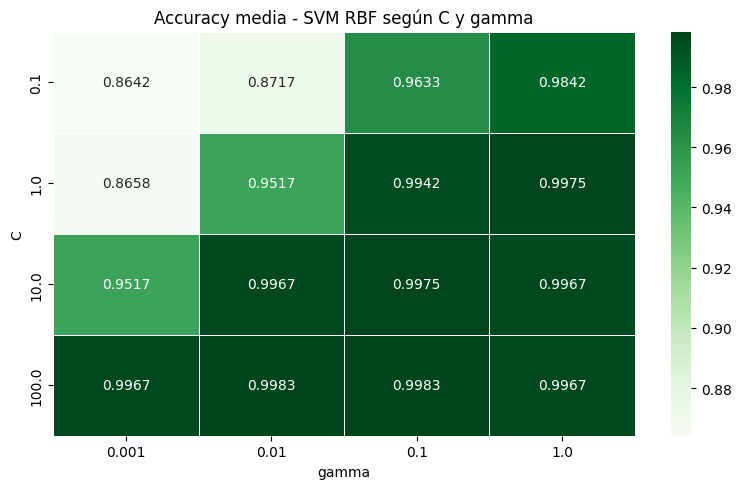

In [ ]:
# Heatmap de Accuracy media según C y gamma

heatmap_rbf = resultados_svm_rbf.pivot(
    index='C',
    columns='gamma',
    values='Accuracy_media'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_rbf,
    annot=True,
    fmt='.4f',
    cmap='Greens',
    linewidths=0.5
)

plt.title('Accuracy media - SVM RBF según C y gamma')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

A partir de los resultados obtenidos mediante validación cruzada estratificada, observamos que el modelo SVM RBF alcanza su mejor rendimiento con 'C = 100'. En particular, las combinaciones 'C = 100, gamma = 0.01' y 'C = 100, gamma = 0.10' obtienen el mismo valor de 'Accuracy_media', con una desviación estándar de 0.0020.

Dado que ambas configuraciones presentan el mismo rendimiento promedio y la misma estabilidad entre folds, decidimos seleccionar 'C = 100' y 'gamma = 0.01'. Esta decisión se basa en que ante dos modelos con igual desempeño, preferimos el que utiliza un valor menor de 'gamma', ya que produce una frontera de decisión más suave y menos dependiente de variaciones locales.

Por lo tanto, conservamos como mejor configuración del SVM RBF: 'C = 100' y 'gamma = 0.01'.

### Random Forest

In [35]:
# Grid de hiperparámetros
# ==============================================================================
valores_n_estimators = [50, 100, 200, 500]
valores_max_depth = [5, 10, 20, None]

resultados_random_forest = []

for n_estimators in valores_n_estimators:
    for max_depth in valores_max_depth:
        
        precision_folds = []
        recall_folds = []
        accuracy_folds = []
        
        for train_index, test_index in skf.split(X_model, y_model):
            
            # División de los datos en entrenamiento y validación
            X_train = X_model.iloc[train_index]
            X_test = X_model.iloc[test_index]
            y_train = y_model[train_index]
            y_test = y_model[test_index]
            
            # Creación del modelo Random Forest
            modelo = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=RANDOM_STATE
            )
            
            modelo.fit(X_train, y_train)
            
            # Predicciones sobre el fold de validación
            predicciones = modelo.predict(X_test)
            
            # Métricas solicitadas
            precision_folds.append(
                precision_score(
                    y_test,
                    predicciones,
                    average='weighted',
                    zero_division=0
                )
            )
            
            recall_folds.append(
                recall_score(
                    y_test,
                    predicciones,
                    average='weighted',
                    zero_division=0
                )
            )
            
            accuracy_folds.append(
                accuracy_score(y_test, predicciones)
            )
        
        resultados_random_forest.append({
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'Precision_media': np.mean(precision_folds),
            'Precision_std': np.std(precision_folds),
            'Recall_media': np.mean(recall_folds),
            'Recall_std': np.std(recall_folds),
            'Accuracy_media': np.mean(accuracy_folds),
            'Accuracy_std': np.std(accuracy_folds)
        })

resultados_random_forest = pd.DataFrame(resultados_random_forest)

display(
    resultados_random_forest
    .sort_values(by='Accuracy_media', ascending=False)
    .round(4)
)

,n_estimators,max_depth,Precision_media,Precision_std,Recall_media,Recall_std,Accuracy_media,Accuracy_std
0,50,5.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
1,50,10.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
2,50,20.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
3,50,NaN,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
4,100,5.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
5,100,10.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
6,100,20.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
7,100,NaN,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
8,200,5.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017
9,200,10.0,0.9992,0.0016,0.9992,0.0017,0.9992,0.0017


Al evaluar las combinaciones de 'n_estimators' y 'max_depth', observamos que todas las configuraciones obtienen el mismo rendimiento promedio: 'Accuracy_media = 0.9992', con una desviación estándar de '0.0017'. Lo mismo ocurre con 'Precision weighted' y 'Recall weighted', que también se mantienen iguales entre combinaciones.

Este resultado es consistente con lo observado en el análisis exploratorio. Las clases presentan patrones muy diferenciados en varias variables predictoras, especialmente en atributos como 'Potasio', 'Humedad' y 'Lluvia'. Por lo tanto, el problema resulta altamente separable para un modelo basado en árboles, incluso utilizando configuraciones simples.

Dado que aumentar la cantidad de árboles o permitir mayor profundidad no mejora las métricas, decidimos seleccionar el modelo menos complejo y de menor costo computacional.

Por este motivo, elegimos como mejor configuración de Random Forest:

- 'n_estimators = 50'
- 'max_depth = 5'

Esta configuración alcanza el mismo rendimiento que las alternativas más complejas, pero utiliza menos árboles y limita la profundidad de cada árbol. De esta manera, mantenemos un modelo más simple, estable y suficiente para el problema analizado.

Luego de seleccionar la mejor configuración de Random Forest, analizamos la importancia de las variables mediante 'feature_importances_'. Esta medida indica qué atributos fueron más utilizados por los árboles del bosque para realizar las divisiones y separar las clases.

Entrenamos el modelo seleccionado sobre el conjunto limpio completo con fines interpretativos. Esta etapa no reemplaza la validación cruzada realizada previamente, sino que nos permite comprender qué variables aportan más información al proceso de clasificación.

In [37]:
modelo_rf_importancias = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=RANDOM_STATE
)

modelo_rf_importancias.fit(X_model, y_model)

# Armamos la tabla de importancias
importancias_rf = pd.DataFrame({
    'Variable': X_model.columns,
    'Importancia': modelo_rf_importancias.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by='Importancia',
    ascending=False
)

importancias_rf['Importancia_%'] = importancias_rf['Importancia'] * 100

display(importancias_rf.round(4))

,Variable,Importancia,Importancia_%
4,Humedad,0.2276,22.7637
2,Potasio,0.2188,21.8791
6,Lluvia,0.2038,20.3794
1,Fosforo,0.1697,16.9679
0,Nitrogeno,0.1039,10.3924
3,Temperatura,0.0509,5.0939
5,pH,0.0252,2.5236


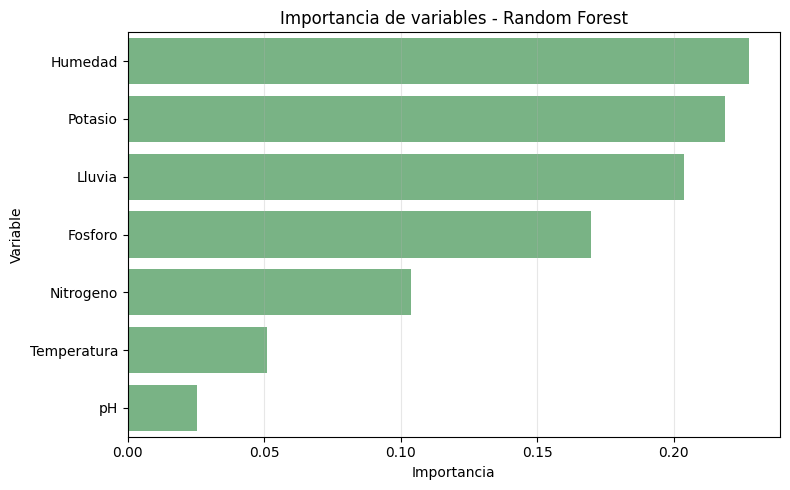

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importancias_rf,
    x='Importancia',
    y='Variable',
    color='#6fbd7f'
)

plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de 'feature_importances_' muestra que las variables más relevantes para Random Forest son 'Humedad', 'Potasio' y 'Lluvia', que en conjunto concentran aproximadamente el 65% de la importancia total. Este resultado coincide con lo observado en el EDA, donde estas variables presentaban rangos claramente diferenciados entre cultivos.

En menor medida aparecen 'Fosforo' y 'Nitrogeno', mientras que 'Temperatura' y 'pH' tienen una importancia relativa más baja. Esto no implica que deban eliminarse, sino que aportan menos capacidad de separación dentro de este modelo. En conjunto, la importancia de variables refuerza que las diferencias detectadas inicialmente no eran ruido, sino información útil para la clasificación.

### Comparación entre modelos

En esta etapa comparamos los tres modelos evaluados: SVM lineal, SVM RBF y Random Forest. Para la tabla comparativa utilizamos las métricas obtenidas mediante validación cruzada estratificada, tomando la mejor configuración de cada algoritmo.

Además, generamos matrices de confusión utilizando un split adicional 80/20 con 'random_state=13'. Esta decisión permite observar de forma más concreta qué clases son correctamente clasificadas y si existen confusiones entre cultivos específicos.

In [42]:
# Recuperamos las mejores configuraciones ya seleccionadas en los puntos anteriores
fila_svm_lineal = resultados_svm_lineal[
    resultados_svm_lineal['C'] == 10
].iloc[0]

fila_svm_rbf = resultados_svm_rbf[
    (resultados_svm_rbf['C'] == 100) &
    (resultados_svm_rbf['gamma'] == 0.01)
].iloc[0]

fila_random_forest = resultados_random_forest[
    (resultados_random_forest['n_estimators'] == 50) &
    (resultados_random_forest['max_depth'] == 5)
].iloc[0]

In [40]:
tabla_comparacion = pd.DataFrame([
    {
        'Modelo': 'SVM lineal',
        'Mejor configuración': 'C = 10',
        'Precision_media': fila_svm_lineal['Precision_media'],
        'Precision_std': fila_svm_lineal['Precision_std'],
        'Recall_media': fila_svm_lineal['Recall_media'],
        'Recall_std': fila_svm_lineal['Recall_std'],
        'Accuracy_media': fila_svm_lineal['Accuracy_media'],
        'Accuracy_std': fila_svm_lineal['Accuracy_std']
    },
    {
        'Modelo': 'SVM RBF',
        'Mejor configuración': 'C = 100, gamma = 0.01',
        'Precision_media': fila_svm_rbf['Precision_media'],
        'Precision_std': fila_svm_rbf['Precision_std'],
        'Recall_media': fila_svm_rbf['Recall_media'],
        'Recall_std': fila_svm_rbf['Recall_std'],
        'Accuracy_media': fila_svm_rbf['Accuracy_media'],
        'Accuracy_std': fila_svm_rbf['Accuracy_std']
    },
    {
        'Modelo': 'Random Forest',
        'Mejor configuración': 'n_estimators = 50, max_depth = 5',
        'Precision_media': fila_random_forest['Precision_media'],
        'Precision_std': fila_random_forest['Precision_std'],
        'Recall_media': fila_random_forest['Recall_media'],
        'Recall_std': fila_random_forest['Recall_std'],
        'Accuracy_media': fila_random_forest['Accuracy_media'],
        'Accuracy_std': fila_random_forest['Accuracy_std']
    }
])

display(tabla_comparacion.round(4))

,Modelo,Mejor configuración,Precision_media,Precision_std,Recall_media,Recall_std,Accuracy_media,Accuracy_std
0,SVM lineal,C = 10,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,SVM RBF,"C = 100, gamma = 0.01",0.9984,0.0019,0.9983,0.0020,0.9983,0.0020
2,Random Forest,"n_estimators = 50, max_depth = 5",0.9992,0.0016,0.9992,0.0017,0.9992,0.0017


In [43]:
# División adicional 80/20
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_model
)

# Escalado para SVM
# ==============================================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelos con las mejores configuraciones seleccionadas
# ==============================================================================
modelo_svm_lineal = SVC(
    C=10,
    kernel='linear',
    random_state=RANDOM_STATE
)

modelo_svm_rbf = SVC(
    C=100,
    gamma=0.01,
    kernel='rbf',
    random_state=RANDOM_STATE
)

modelo_random_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=RANDOM_STATE
)

# Entrenamiento
# ==============================================================================
modelo_svm_lineal.fit(X_train_scaled, y_train)
modelo_svm_rbf.fit(X_train_scaled, y_train)
modelo_random_forest.fit(X_train, y_train)

# Predicciones
# ==============================================================================
pred_svm_lineal = modelo_svm_lineal.predict(X_test_scaled)
pred_svm_rbf = modelo_svm_rbf.predict(X_test_scaled)
pred_random_forest = modelo_random_forest.predict(X_test)

In [44]:
def mostrar_matriz_confusion(y_real, y_pred, titulo):
    matriz = confusion_matrix(y_real, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    disp.plot(
        ax=ax,
        cmap='Greens',
        xticks_rotation=45,
        colorbar=False
    )

    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

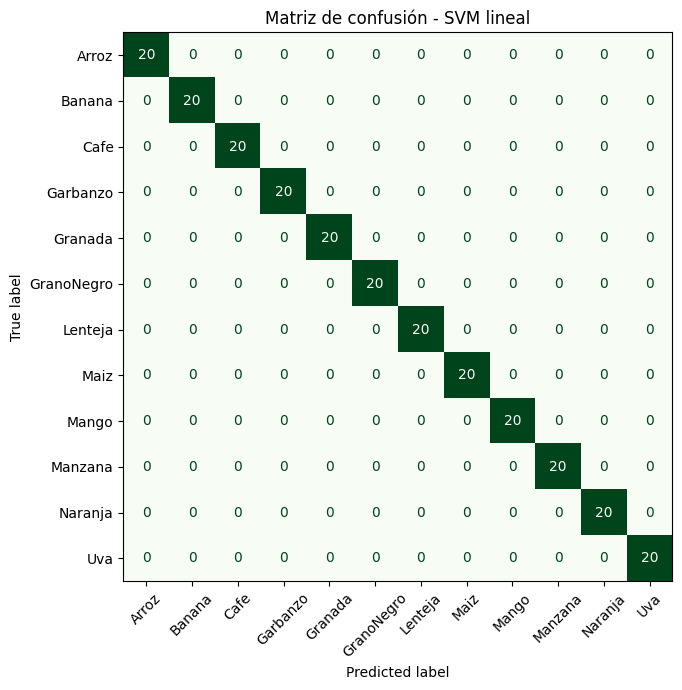

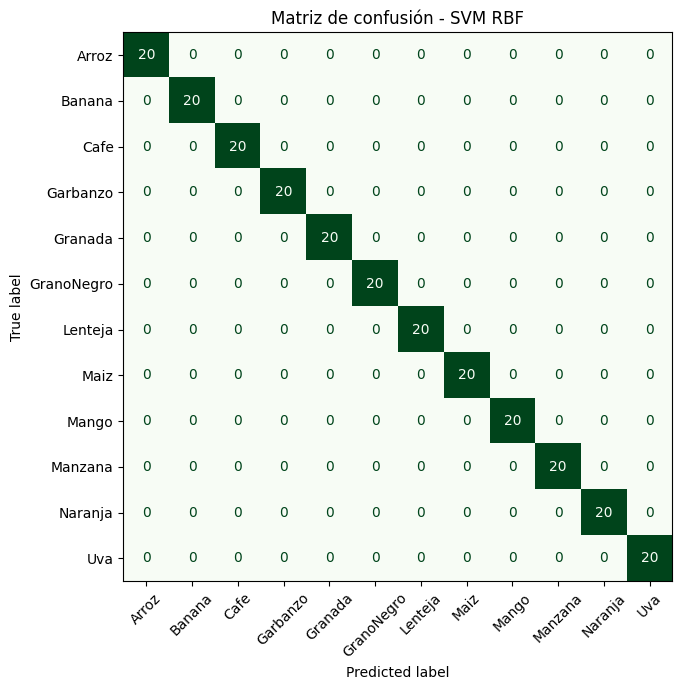

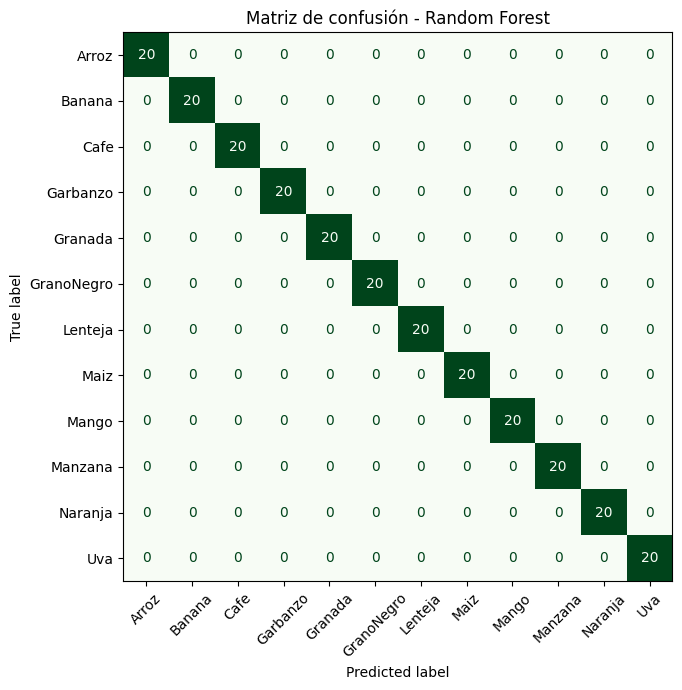

In [45]:
# Matrices de confusión
# ==============================================================================
mostrar_matriz_confusion(
    y_test,
    pred_svm_lineal,
    'Matriz de confusión - SVM lineal'
)

mostrar_matriz_confusion(
    y_test,
    pred_svm_rbf,
    'Matriz de confusión - SVM RBF'
)

mostrar_matriz_confusion(
    y_test,
    pred_random_forest,
    'Matriz de confusión - Random Forest'
)

Las matrices de confusión muestran que los tres modelos clasifican correctamente las 240 observaciones del conjunto de test. En cada caso, los valores se concentran completamente sobre la diagonal principal, con 20 aciertos por cada cultivo y sin errores fuera de la diagonal.

Este resultado confirma lo observado en la validación cruzada: el problema presenta clases altamente separables a partir de las variables disponibles. Por lo tanto, no se identifican confusiones relevantes entre cultivos para ninguno de los tres algoritmos evaluados.

A partir de estas matrices, SVM lineal, SVM RBF y Random Forest muestran un desempeño perfecto sobre el split 80/20 utilizado para esta comparación visual.

### Selección del modelo final

A partir de la comparación general, seleccionamos como modelo final el **SVM con kernel lineal y 'C = 10'**.

Esta decisión se fundamenta en que fue el único modelo que obtuvo métricas perfectas en la validación cruzada estratificada, con 'Precision weighted', 'Recall weighted' y 'Accuracy' iguales a 1.0000, además de una desviación estándar igual a 0.0000. Esto indica no solo un rendimiento máximo, sino también una estabilidad completa entre folds.

Las matrices de confusión muestran que los tres modelos clasifican correctamente todas las observaciones del split 80/20. Sin embargo, al comparar los resultados de validación cruzada, SVM lineal presenta una leve ventaja sobre SVM RBF y Random Forest. Además, al utilizar una frontera lineal, resulta menos complejo que el kernel RBF y no requiere el costo adicional de entrenar múltiples árboles como Random Forest.

Random Forest aporta mayor interpretabilidad mediante la importancia de variables, lo cual permitió identificar que 'Humedad', 'Potasio' y 'Lluvia' fueron las variables más relevantes. Sin embargo, dado que el objetivo principal del punto es seleccionar el modelo más adecuado para clasificación, priorizamos el rendimiento, la estabilidad y la simplicidad del modelo.

Por lo tanto, consideramos que el modelo más adecuado para este problema es **SVM lineal con 'C = 10'**, ya que logra el mejor desempeño global con una estructura simple, estable y suficiente para separar correctamente las clases del conjunto de datos.

### Conclusión

A lo largo del trabajo logramos construir un proceso completo de clasificación multiclase para la recomendación de cultivos a partir de variables de suelo y clima. Luego de la limpieza inicial, el dataset quedó conformado por 1200 registros, con 100 observaciones para cada uno de los 12 cultivos. Esta distribución balanceada permitió evaluar los modelos sin que una clase tuviera mayor peso real que otra, aunque mantuvimos las métricas weighted porque eran las solicitadas por la consigna.

En la etapa exploratoria observamos que las diferencias más marcadas entre cultivos aparecían principalmente en 'Humedad', 'Potasio' y 'Lluvia'. Al principio estos valores parecían posibles outliers en las distribuciones generales, pero al analizarlos por cultivo comprobamos que respondían a patrones propios de cada clase. Por eso decidimos no eliminar registros por valores extremos, ya que hacerlo habría significado quitar información útil para la clasificación.

En cuanto a los modelos, los tres algoritmos obtuvieron desempeños muy altos. SVM RBF y Random Forest alcanzaron resultados prácticamente perfectos, pero el SVM lineal con 'C = 10' fue el único que logró métricas iguales a 1.0000 en validación cruzada, con desviación estándar nula. Además, las matrices de confusión del split 80/20 mostraron una clasificación perfecta para los tres modelos, con 20 aciertos por cultivo y sin errores fuera de la diagonal.

A partir de estos resultados, seleccionamos como modelo final el SVM lineal. Esta elección no se basa únicamente en que obtuvo el mejor rendimiento, sino también en su estabilidad y menor complejidad frente al kernel RBF y Random Forest. Dado que una frontera lineal fue suficiente para separar correctamente los cultivos, no encontramos justificación para preferir un modelo más complejo.

Finalmente, el análisis de importancia de variables en Random Forest reforzó lo observado durante el EDA: 'Humedad', 'Potasio' y 'Lluvia' fueron las variables más relevantes para distinguir los cultivos. Esto nos permitió cerrar el trabajo con una lectura consistente entre la exploración inicial, el comportamiento de los modelos y la interpretación del problema.